In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r'C:\Users\aruna\Desktop\Work\MLDAY1')

df = pd.read_csv('train.csv')
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(20))


(1460, 81)
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


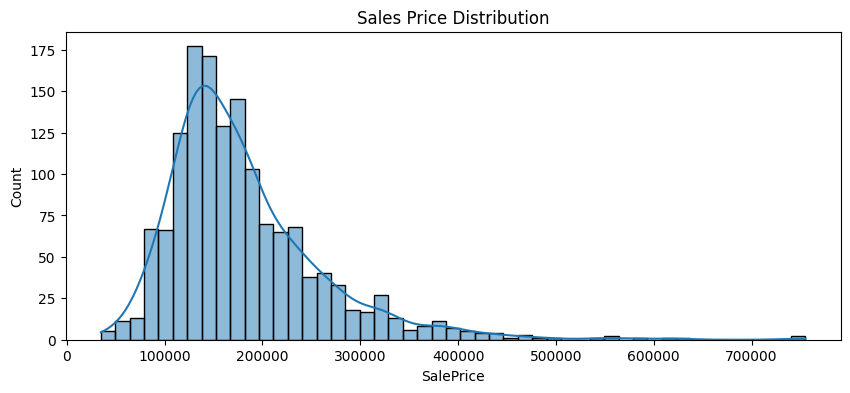

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [2]:
plt.figure(figsize=(10,4))
sns.histplot(df['SalePrice'],kde=True)
plt.title('Sales Price Distribution')
plt.show()

print(df['SalePrice'].describe())

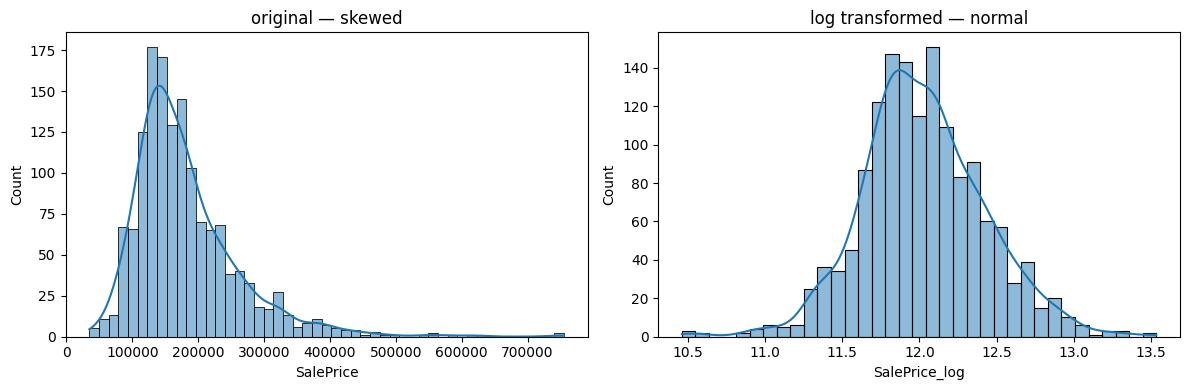

In [3]:
import numpy as np

# apply log transformation
df['SalePrice_log'] = np.log(df['SalePrice'])

# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title('original — skewed')
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])

axes[1].set_title('log transformed — normal')
sns.histplot(df['SalePrice_log'], kde=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [4]:
correlation = df.corr(numeric_only=True)['SalePrice_log'].sort_values(ascending=False)
print(correlation.head(11))

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
Name: SalePrice_log, dtype: float64


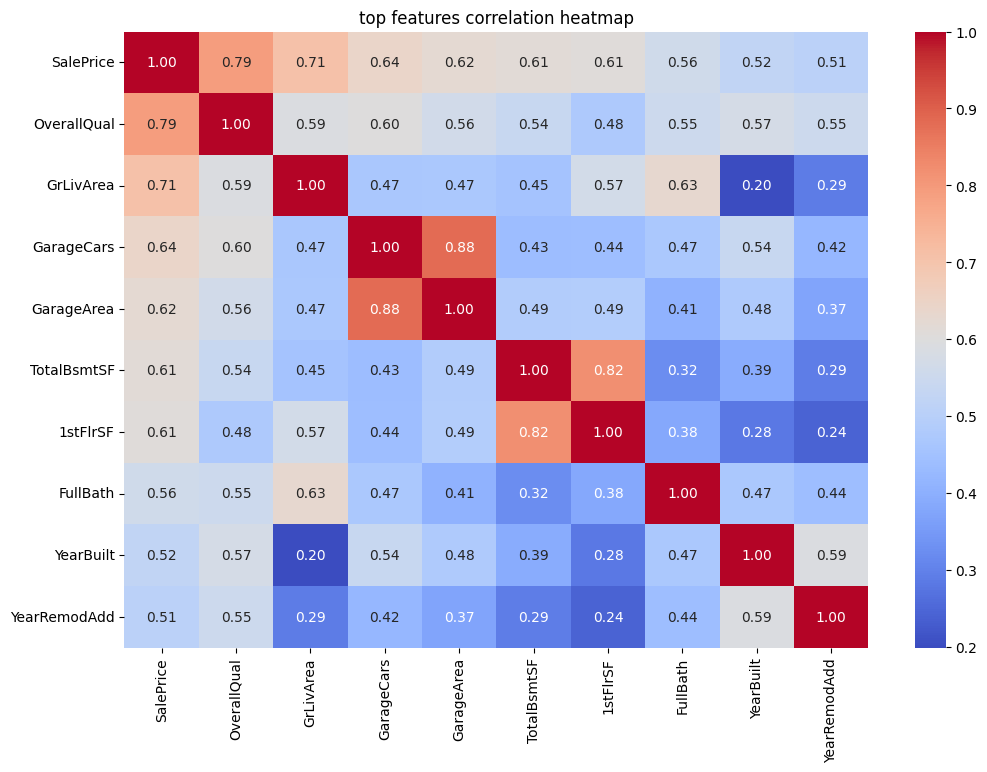

In [5]:
# select top correlated columns
top_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 
            'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 
            'YearBuilt', 'YearRemodAdd']

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('top features correlation heatmap')
plt.show()

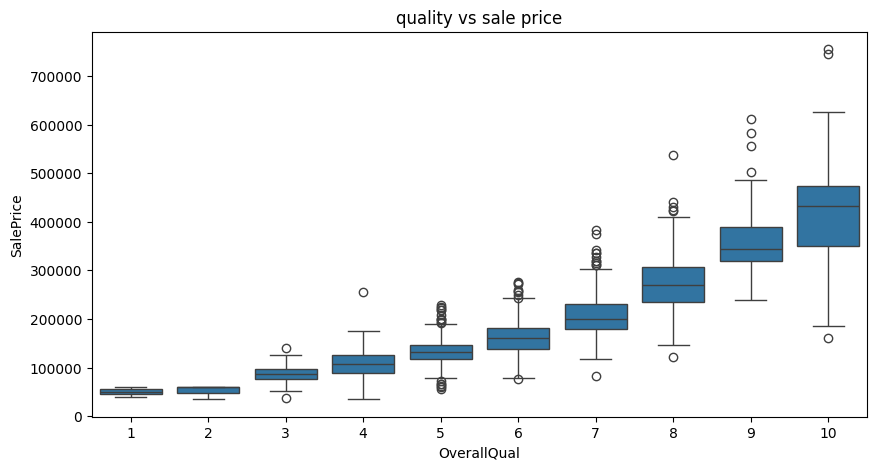

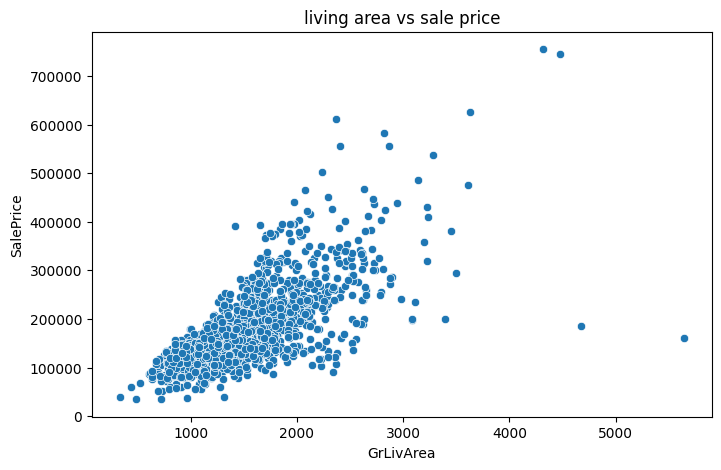

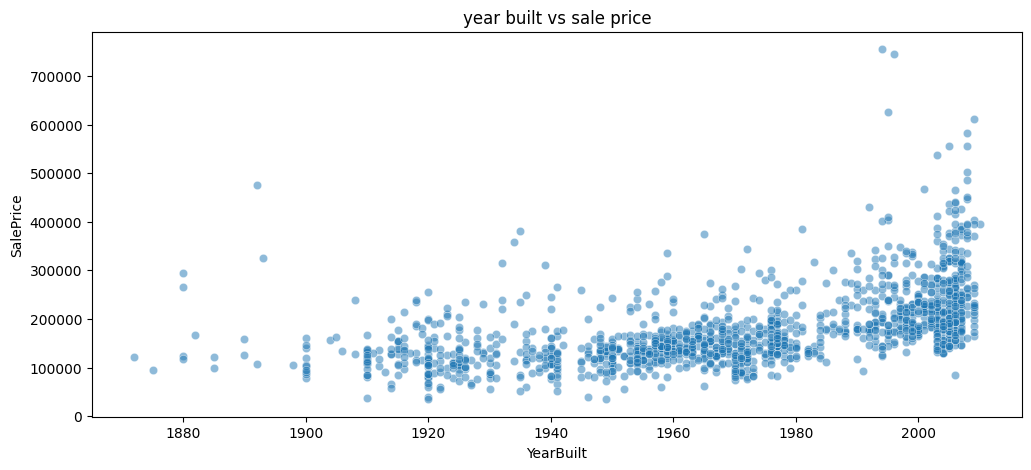

In [6]:
# 1. overall quality vs price — most important feature
plt.figure(figsize=(10, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('quality vs sale price')
plt.show()

# 2. living area vs price — scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('living area vs sale price')
plt.show()

# 3. year built vs price
plt.figure(figsize=(12, 5))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df, alpha=0.5)
plt.title('year built vs sale price')
plt.show()